<a href="https://colab.research.google.com/github/MHHamdan/.github/blob/main/distance_metrics_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Distance Measurement Algorithms: Implementation and Visualization

This notebook provides a comprehensive implementation of various distance metrics with practical examples and visualizations.

## Table of Contents
1. Setup and Imports
2. Distance Metric Implementations
3. Visualization Functions
4. Practical Examples
5. Performance Analysis

## 1. Setup and Imports

First, let's import all necessary libraries and set up our environment.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting style
# plt.style.use('seaborn')  # Remove or comment out this line
sns.set_theme(style="whitegrid")

## 2. Distance Metric Implementations

Let's implement our four main distance metrics:
- Manhattan Distance (L1)
- Euclidean Distance (L2)
- Cosine Distance
- Dot Product Similarity

In [3]:
def manhattan_distance(point1, point2):
    """Calculate Manhattan (L1) distance between two points."""
    return np.sum(np.abs(point1 - point2))

def euclidean_distance(point1, point2):
    """Calculate Euclidean (L2) distance between two points."""
    return np.sqrt(np.sum((point1 - point2)**2))

def cosine_distance(vector1, vector2):
    """Calculate Cosine distance between two vectors."""
    dot_product = np.dot(vector1, vector2)
    norms = np.linalg.norm(vector1) * np.linalg.norm(vector2)
    return 1 - dot_product/norms

def dot_product_similarity(vector1, vector2):
    """Calculate Dot product similarity between two vectors."""
    return np.dot(vector1, vector2)

## 3. Visualization Functions

Now let's create functions to visualize these distances in 2D space.

In [4]:
def plot_2d_points(points, title="2D Points"):
    """Plot points in 2D space."""
    plt.figure(figsize=(10, 8))
    plt.scatter(points[:, 0], points[:, 1], c='blue', alpha=0.6)
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

def visualize_distances(point1, point2, title="Distance Visualization"):
    """Visualize different distances between two points."""
    plt.figure(figsize=(12, 8))

    # Plot points
    plt.scatter([point1[0], point2[0]], [point1[1], point2[1]],
                c='red', s=100)

    # Euclidean distance
    plt.plot([point1[0], point2[0]], [point1[1], point2[1]],
             'b--', label='Euclidean')

    # Manhattan distance
    plt.plot([point1[0], point2[0]], [point1[1], point1[1]],
             'g:', label='Manhattan (part 1)')
    plt.plot([point2[0], point2[0]], [point1[1], point2[1]],
             'g:', label='Manhattan (part 2)')

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.legend()
    plt.show()

## 4. Practical Example: Comparing Distances

Let's create some example points and compare different distance metrics.

Distances between points:
Manhattan Distance: 7.00
Euclidean Distance: 5.00
Cosine Distance: 0.00
Dot Product Similarity: 31.00


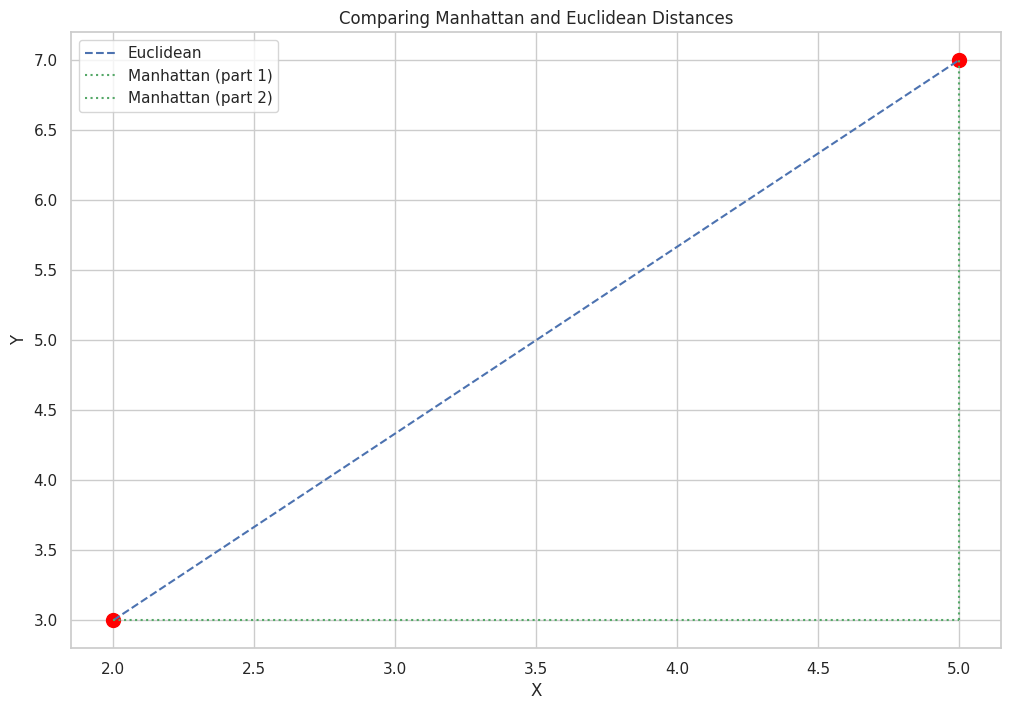

In [5]:
# Create two specific points for detailed comparison
point_a = np.array([2, 3])
point_b = np.array([5, 7])

# Calculate distances
print("Distances between points:")
print(f"Manhattan Distance: {manhattan_distance(point_a, point_b):.2f}")
print(f"Euclidean Distance: {euclidean_distance(point_a, point_b):.2f}")
print(f"Cosine Distance: {cosine_distance(point_a, point_b):.2f}")
print(f"Dot Product Similarity: {dot_product_similarity(point_a, point_b):.2f}")

# Visualize the distances
visualize_distances(point_a, point_b, "Comparing Manhattan and Euclidean Distances")

## 5. Document Similarity Example

Let's see how these metrics work for document similarity comparison.

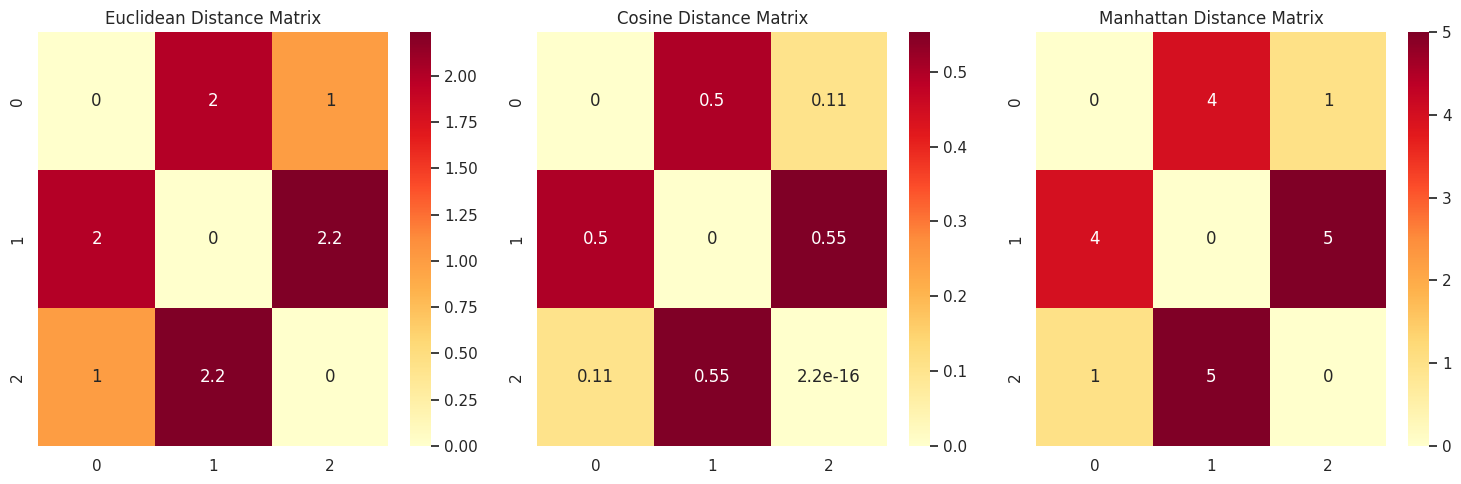

In [6]:
# Create sample document vectors (word frequencies)
doc1 = np.array([1, 1, 0, 0, 1, 0, 1])  # Example document 1
doc2 = np.array([0, 1, 1, 0, 0, 1, 1])  # Example document 2
doc3 = np.array([1, 1, 0, 1, 1, 0, 1])  # Example document 3

# Stack documents into a matrix
docs = np.vstack([doc1, doc2, doc3])

# Calculate similarity matrices
euclidean_matrix = cdist(docs, docs, metric='euclidean')
cosine_matrix = cdist(docs, docs, metric='cosine')
manhattan_matrix = cdist(docs, docs, metric='cityblock')

# Visualize matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Euclidean', 'Cosine', 'Manhattan']
matrices = [euclidean_matrix, cosine_matrix, manhattan_matrix]

for ax, metric, matrix in zip(axes, metrics, matrices):
    sns.heatmap(matrix, ax=ax, annot=True, cmap='YlOrRd')
    ax.set_title(f'{metric} Distance Matrix')

plt.tight_layout()
plt.show()

## 6. Performance Analysis

Let's compare the computational performance of different distance metrics.

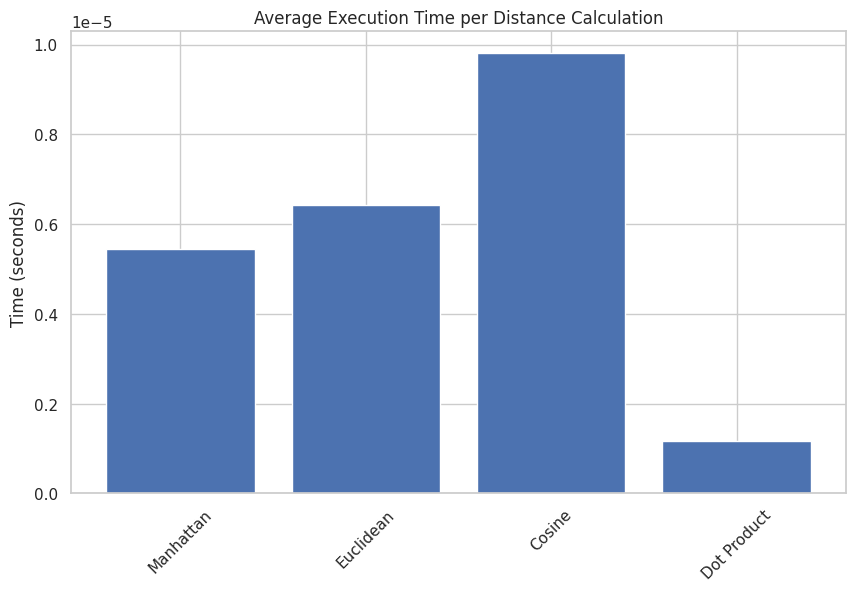

In [7]:
import time

def measure_performance(func, point1, point2, n_iterations=100000):
    """Measure the execution time of a distance function."""
    start_time = time.time()
    for _ in range(n_iterations):
        _ = func(point1, point2)
    end_time = time.time()
    return (end_time - start_time) / n_iterations

# Compare performance
distance_functions = [
    (manhattan_distance, "Manhattan"),
    (euclidean_distance, "Euclidean"),
    (cosine_distance, "Cosine"),
    (dot_product_similarity, "Dot Product")
]

performance_results = []
for func, name in distance_functions:
    avg_time = measure_performance(func, point_a, point_b)
    performance_results.append((name, avg_time))

# Plot results
names, times = zip(*performance_results)
plt.figure(figsize=(10, 6))
plt.bar(names, times)
plt.title("Average Execution Time per Distance Calculation")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=45)
plt.show()

## Conclusion

In this notebook, we've:
1. Implemented four different distance metrics
2. Visualized how these metrics work in 2D space
3. Compared their performance
4. Demonstrated their use in document similarity

Key takeaways:
- Each metric has its own strengths and use cases
- Manhattan distance is useful for grid-based problems
- Euclidean distance is intuitive for physical space
- Cosine distance is great for high-dimensional data
- Performance varies between metrics

For more information, check out the accompanying blog post and documentation.